In [3]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.metrics import accuracy_score

In [4]:
# Load the dataset
df = pd.read_csv(r"C:\Users\LENOVO\OneDrive\Desktop\DAATASET\tested.csv") 

In [5]:
# Drop unnecessary columns
df_model = df.drop(columns=["PassengerId", "Name", "Ticket", "Cabin"])

In [6]:
# Handle missing values
# Impute Age with median
df_model["Age"] = df_model["Age"].fillna(df_model["Age"].median())

In [7]:
# Impute Fare with median (if necessary)
df_model["Fare"] = df_model["Fare"].fillna(df_model["Fare"].median())

In [8]:
# Fill Embarked with mode
df_model["Embarked"] = df_model["Embarked"].fillna(df_model["Embarked"].mode()[0])

In [9]:
# Encode categorical features
label_encoder = LabelEncoder()
df_model["Sex"] = label_encoder.fit_transform(df_model["Sex"])          # male=1, female=0
df_model["Embarked"] = label_encoder.fit_transform(df_model["Embarked"])# S=2, C=0, Q=1

In [10]:
# Define features and target
X = df_model.drop("Survived", axis=1)
y = df_model["Survived"]

In [11]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [12]:
# Feature scaling for models that need it
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [13]:
# Initialize models
log_reg = LogisticRegression(random_state=42)
rf_clf = RandomForestClassifier(random_state=42)
svm_clf = SVC(random_state=42)

In [14]:
# Train models
log_reg.fit(X_train_scaled, y_train)
rf_clf.fit(X_train, y_train)  # No scaling needed
svm_clf.fit(X_train_scaled, y_train)

SVC(random_state=42)

In [15]:
# Make predictions
y_pred_log = log_reg.predict(X_test_scaled)
y_pred_rf = rf_clf.predict(X_test)
y_pred_svm = svm_clf.predict(X_test_scaled)

In [16]:
# Evaluate models
acc_log = accuracy_score(y_test, y_pred_log)
acc_rf = accuracy_score(y_test, y_pred_rf)
acc_svm = accuracy_score(y_test, y_pred_svm)

In [17]:
# Print results
print(f"Logistic Regression Accuracy: {acc_log:.4f}")
print(f"Random Forest Accuracy:      {acc_rf:.4f}")
print(f"SVM Accuracy:                {acc_svm:.4f}")

Logistic Regression Accuracy: 1.0000
Random Forest Accuracy:      1.0000
SVM Accuracy:                0.9881


In [18]:
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

In [19]:
# Model names and accuracies
models = ['Logistic Regression', 'Random Forest', 'SVM']
accuracies = [acc_log, acc_rf, acc_svm]

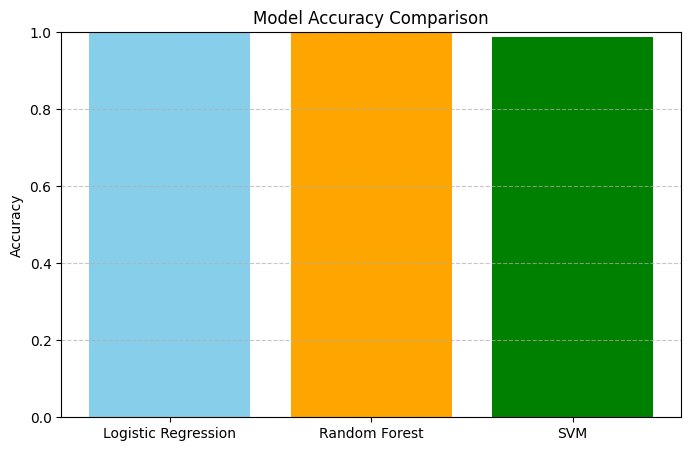

In [20]:
# Plot
plt.figure(figsize=(8, 5))
plt.bar(models, accuracies, color=['skyblue', 'orange', 'green'])
plt.ylim(0, 1)
plt.title('Model Accuracy Comparison')
plt.ylabel('Accuracy')
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

Logistic Regression Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

Random Forest Report:
               precision    recall  f1-score   support

           0       1.00      1.00      1.00        50
           1       1.00      1.00      1.00        34

    accuracy                           1.00        84
   macro avg       1.00      1.00      1.00        84
weighted avg       1.00      1.00      1.00        84

SVM Report:
               precision    recall  f1-score   support

           0       0.98      1.00      0.99        50
           1       1.00      0.97      0.99        34

    accuracy                           0.99        84
   macro avg       0.99      0.99      0.99        84
weighted 

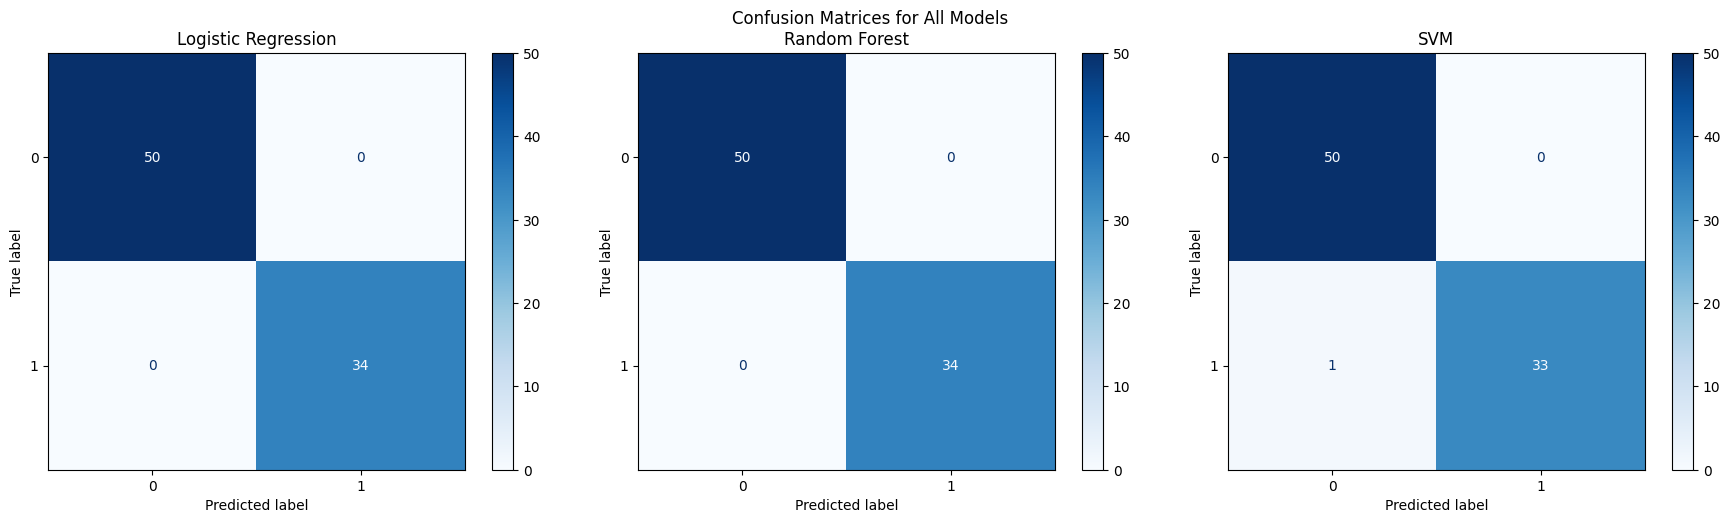

In [21]:
# Print classification reports
print("Logistic Regression Report:\n", classification_report(y_test, y_pred_log))
print("Random Forest Report:\n", classification_report(y_test, y_pred_rf))
print("SVM Report:\n", classification_report(y_test, y_pred_svm))

# Plot confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models = {
    "Logistic Regression": y_pred_log,
    "Random Forest": y_pred_rf,
    "SVM": y_pred_svm
}

for ax, (model_name, preds) in zip(axes, models.items()):
    cm = confusion_matrix(y_test, preds)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm)
    disp.plot(ax=ax, values_format='d', cmap='Blues')
    ax.set_title(model_name)

plt.suptitle("Confusion Matrices for All Models")
plt.tight_layout()
plt.show()